# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** → dense region  
2. **Border point** → not dense itself, but within `eps` of a core point  
3. **Noise point** → neither core nor border (isolated points)
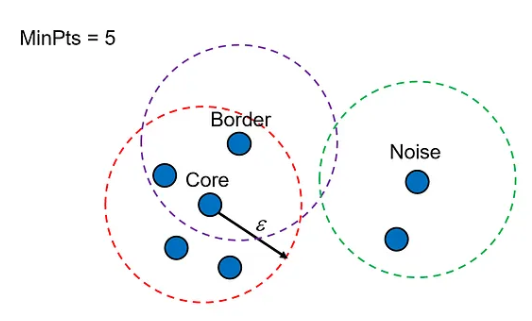

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` → more points are labeled as **noise**  

- Larger `eps` → clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller → clusters form more easily, fewer noise points

- Larger → only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered “neighbors”

**Default:** `euclidean`

**Common options:**  
  - `euclidean` → straight-line distance; most common for numeric features  
  - `manhattan` → sum of absolute differences; robust to outliers  
  - `cosine` → measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

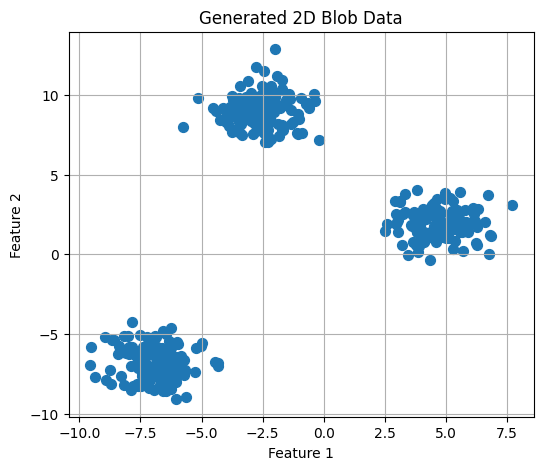

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [ ]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

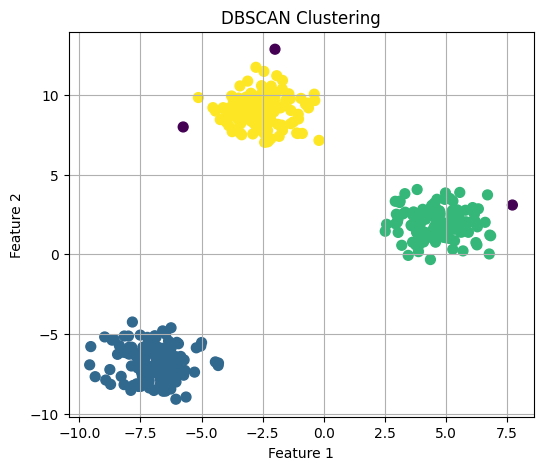

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [ ]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

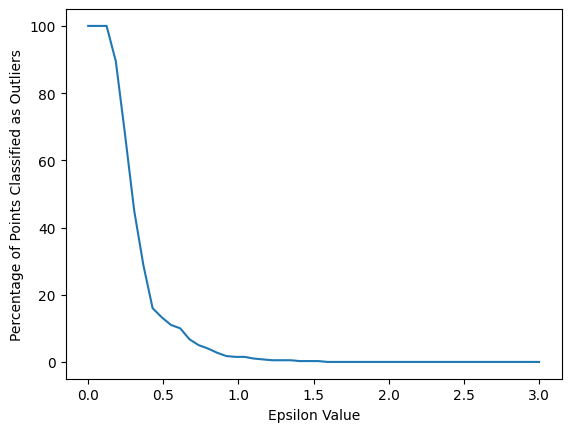

In [ ]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

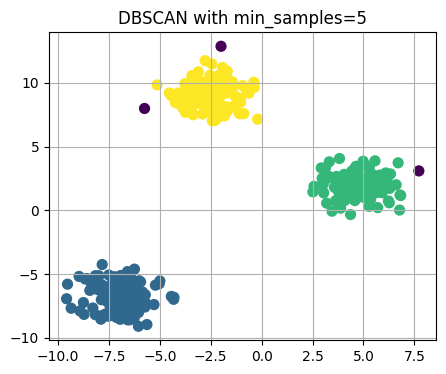

min_samples=5 → Silhouette Score: 0.848


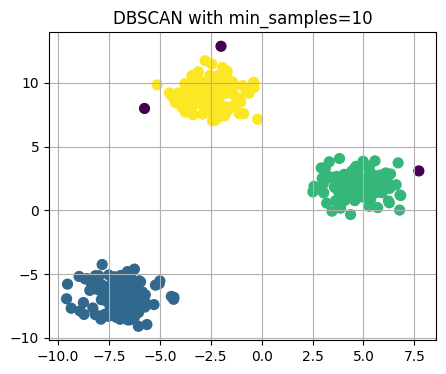

min_samples=10 → Silhouette Score: 0.848


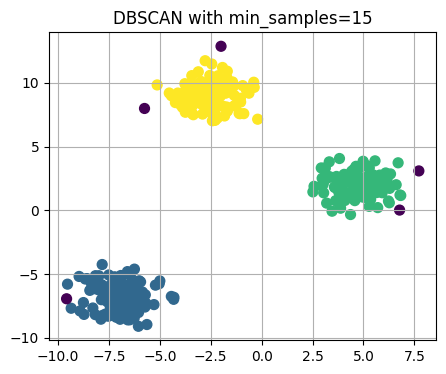

min_samples=15 → Silhouette Score: 0.849


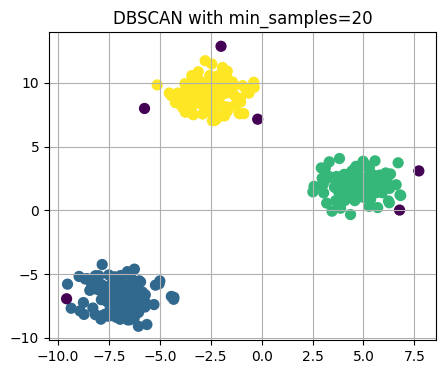

min_samples=20 → Silhouette Score: 0.850


In [ ]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} → Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
df = pd.read_csv('CC GENERAL.csv')

print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print(f"\nDataset shape: {df.shape}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64

In [2]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Categorical features: ['CUST_ID']


In [3]:
for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


CUST_ID
CUST_ID
C10001    1
C16135    1
C16129    1
C16130    1
C16131    1
         ..
C13065    1
C13064    1
C13063    1
C13062    1
C19190    1
Name: count, Length: 8950, dtype: int64


In [4]:
missing = df.isnull().sum()
print(missing[missing > 0])

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


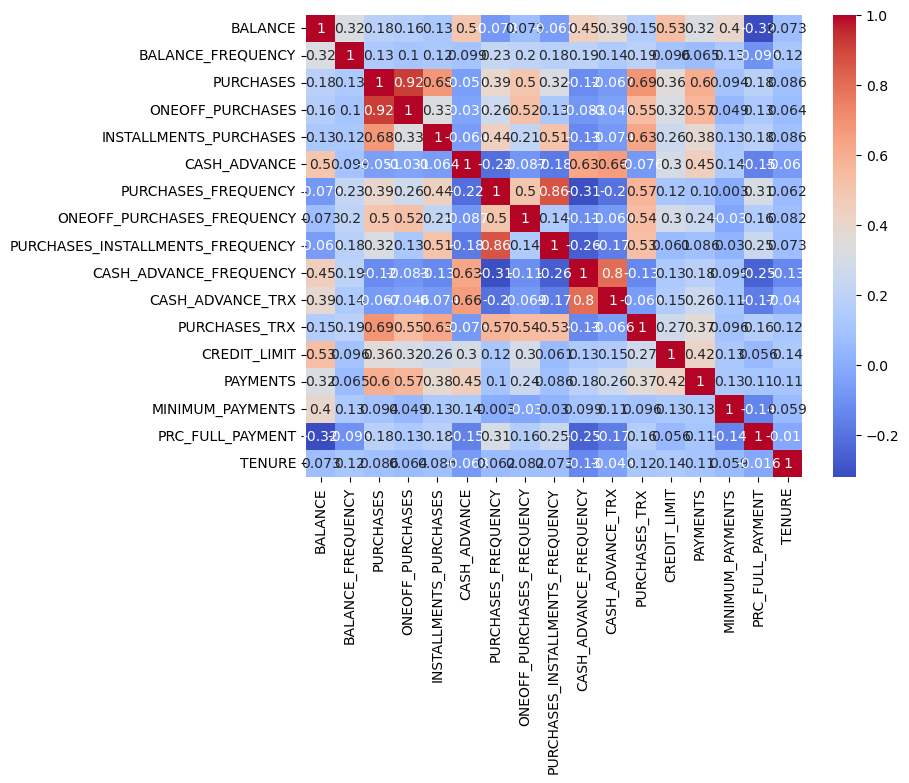

In [5]:
corr_matrix = df[numeric_features].corr()
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

## 2. Data Preparation

In [6]:
# ================================
# 1️⃣ Drop columns FIRST
# ================================

X = df.drop(columns=['CUST_ID', 'ONEOFF_PURCHASES'], errors='ignore')

# ================================
# 2️⃣ Recalculate feature types
# ================================

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# ================================
# 3️⃣ Fill missing values
# ================================

X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())
X[categorical_features] = X[categorical_features].fillna("Unknown")

In [7]:
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Categorical features:", categorical_features)

# Apply one-hot encoding (only if they exist)
if categorical_features:
    X = pd.get_dummies(X, columns=categorical_features, drop_first=False)

print("After encoding:")
print(X.dtypes)



Categorical features: []
After encoding:
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling complete.")



Scaling complete.


In [9]:
import numpy as np

print("Any missing values left?:", np.isnan(X_scaled).sum())
print("All features numeric?:", all([np.issubdtype(dtype, np.number) for dtype in X.dtypes]))

print("Final dataset shape:", X_scaled.shape)

Any missing values left?: 0
All features numeric?: True
Final dataset shape: (8950, 16)


## 3. Apply DBSCAN




In [30]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=2.5, min_samples=50)
clusters = model.fit_predict(X_scaled)

print("Cluster labels:", set(clusters))

Cluster labels: {np.int64(0), np.int64(-1)}


In [31]:
import numpy as np

unique, counts = np.unique(clusters, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(542), np.int64(0): np.int64(8408)}


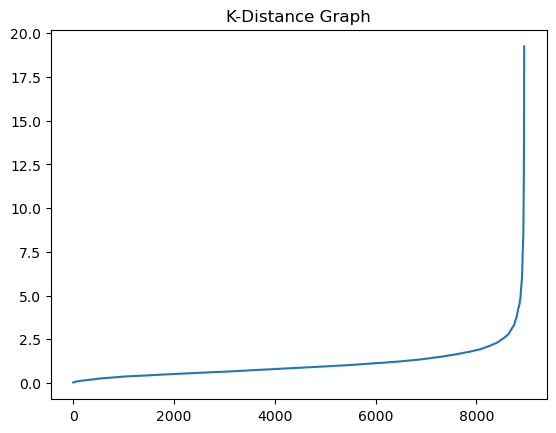

In [32]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])  # 4 because n_neighbors=5
plt.plot(distances)
plt.title("K-Distance Graph")
plt.show()

## 4. Evaluate the Clustering

In [33]:
from sklearn.metrics import silhouette_score
import numpy as np

# Remove noise points (-1)
mask = clusters != -1

if len(set(clusters[mask])) > 1:
    score = silhouette_score(X_scaled[mask], clusters[mask])
    print("Silhouette Score:", score)
else:
    print("Not enough clusters to compute silhouette.")

Not enough clusters to compute silhouette.


In [34]:
import numpy as np

unique_labels = set(clusters)

# Remove noise label (-1)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

print("Cluster labels:", unique_labels)
print("Number of clusters:", n_clusters)

Cluster labels: {np.int64(0), np.int64(-1)}
Number of clusters: 1


In [ ]:
# according to the previous results, it was obivious that no silhouette was going to get compute since the number of clusters is only 1
# but if we think of it, they are actually 2, one for the real cluster and the other one (-1) which corresponds to the noise